# Análisis Exploratorio Para el Problema de Clasificación (PCOS Diagnosis)


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal, f_oneway
from pathlib import Path

In [21]:
ds_path = Path("../ml-project/data/raw/dataset_clasification.csv")
data = pd.read_csv(ds_path, sep=",")

images_dir = Path("./plots")

pd.set_option("display.max_columns", None)

In [22]:
# Lista de todas las variables del dataset
var_num = data.select_dtypes(include=[np.int64, np.float64]).columns.tolist()
var_cat = data.select_dtypes(include=['string']).columns.tolist()

(data[var_num[0]]).min()

np.int64(15)

| Variable | Descripción | Tipo de Dato |
| :--- | :--- | :--- |
| **`Country`** | País de residencia de la paciente (75 países incluidos). | Categórica nominal |
| **`Age`** | Edad de la paciente. | Numérica discreta|
| **`BMI`** | Índice de Masa Corporal categorizado. | Categórica ordinal |
| **`Menstrual Regularity`** | Indica si el ciclo es regular o irregular. | Categórica nominal (binaria) |
| **`Hirsutism`** | Presencia de vello corporal excesivo. | Categórica nominal (binaria) |
| **`Acne Severity`** | Nivel de severidad del acné. | Categórica ordinal (binaria) |
| **`Family History of PCOS`** | Antecedentes de la condición en la familia. | Categórica nominal (binaria) |
| **`Insulin Resistance`** | Presencia de resistencia a la insulina. | Categórica nominal (binaria) |
| **`Lifestyle Score`** | Evaluación de hábitos de vida (dieta, ejercicio, etc.). | Numérica discreta |
| **`Stress Levels`** | Nivel de estrés reportado (Low, Medium, High). | Categórica ordinal |
| **`Urban/Rural`** | Tipo de entorno de vivienda. | Categórica nominal (binaria) |
| **`Socioeconomic Status`** | Nivel de ingresos/estatus social. | Categórica ordinal |
| **`Awareness of PCOS`** | Conocimiento previo de la paciente sobre la enfermedad. | Categórica nominal (binaria) |
| **`Fertility Concerns`** | Si la paciente tiene preocupaciones sobre su fertilidad. | Categórica nominal (binaria) |
| **`Undiagnosed PCOS Likelihood`** | Estimación estadística de probabilidad previa. | Numérica continua |
| **`Ethnicity`** | Grupo étnico de la paciente. | Categórica nominal |
| **`Diagnosis`** | **Variable Objetivo**: Confirmación del diagnóstico. | Categórica nominal (binaria) |

## Histograma de las variables

/tmp/ipykernel_115245/1288720748.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


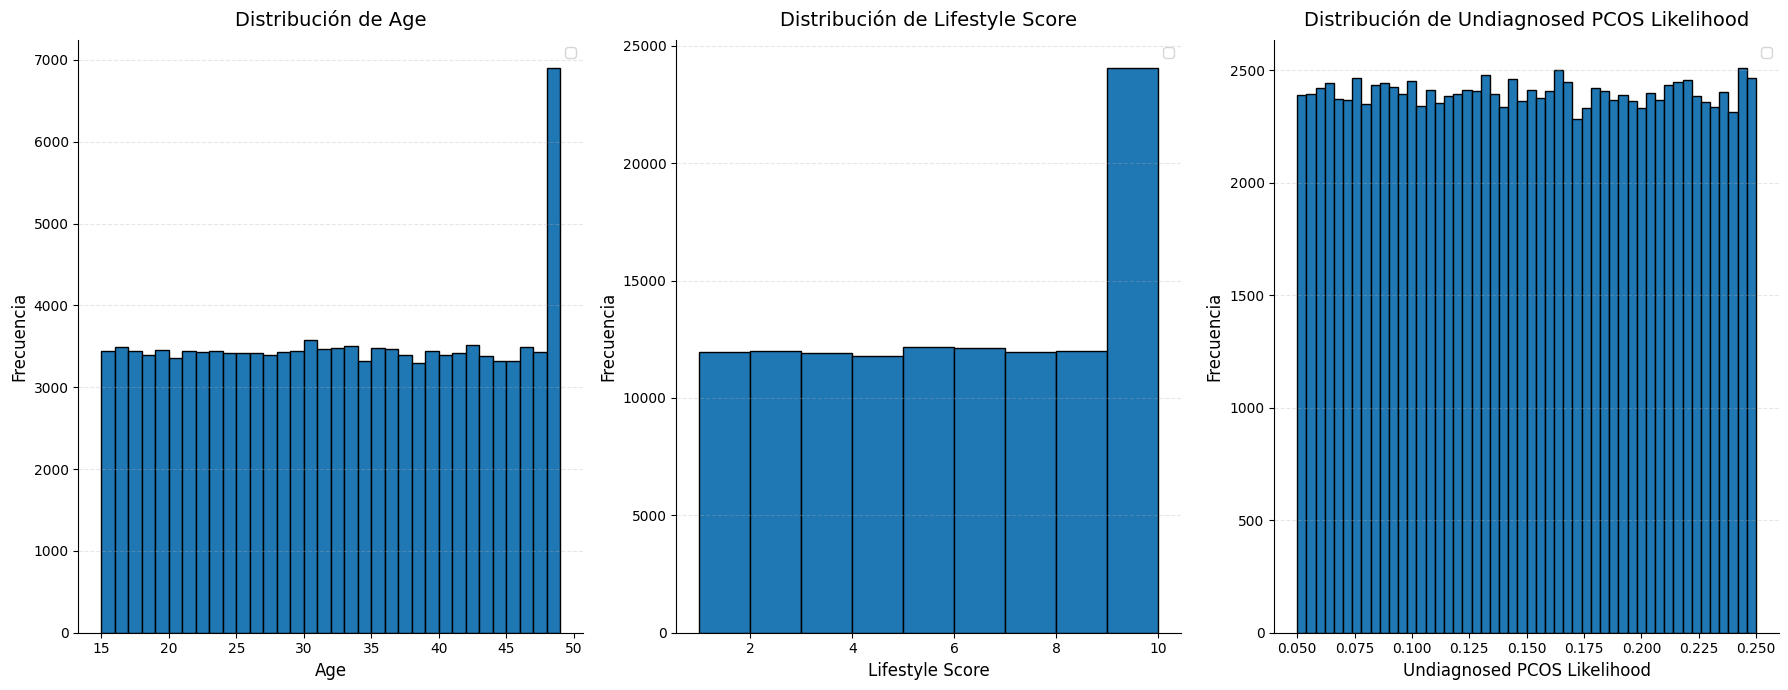

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes = axes.ravel()
colores = ['#4C72B0', '#55A868', '#C44E52']

for i, var in enumerate(var_num):
    valores = data[var].dropna()
    axes[i].hist(valores, bins='auto', alpha=1, edgecolor='black')
    axes[i].legend()
    axes[i].set_title(f"Distribución de {var}", fontsize=14, pad=10)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel("Frecuencia", fontsize=12)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')

sns.despine() if 'sns' in globals() else [ax.spines[side].set_visible(False) for ax in axes for side in ['top', 'right']]
plt.tight_layout()
plt.savefig(images_dir / "clasi_var_num_histograms.png")
plt.show()

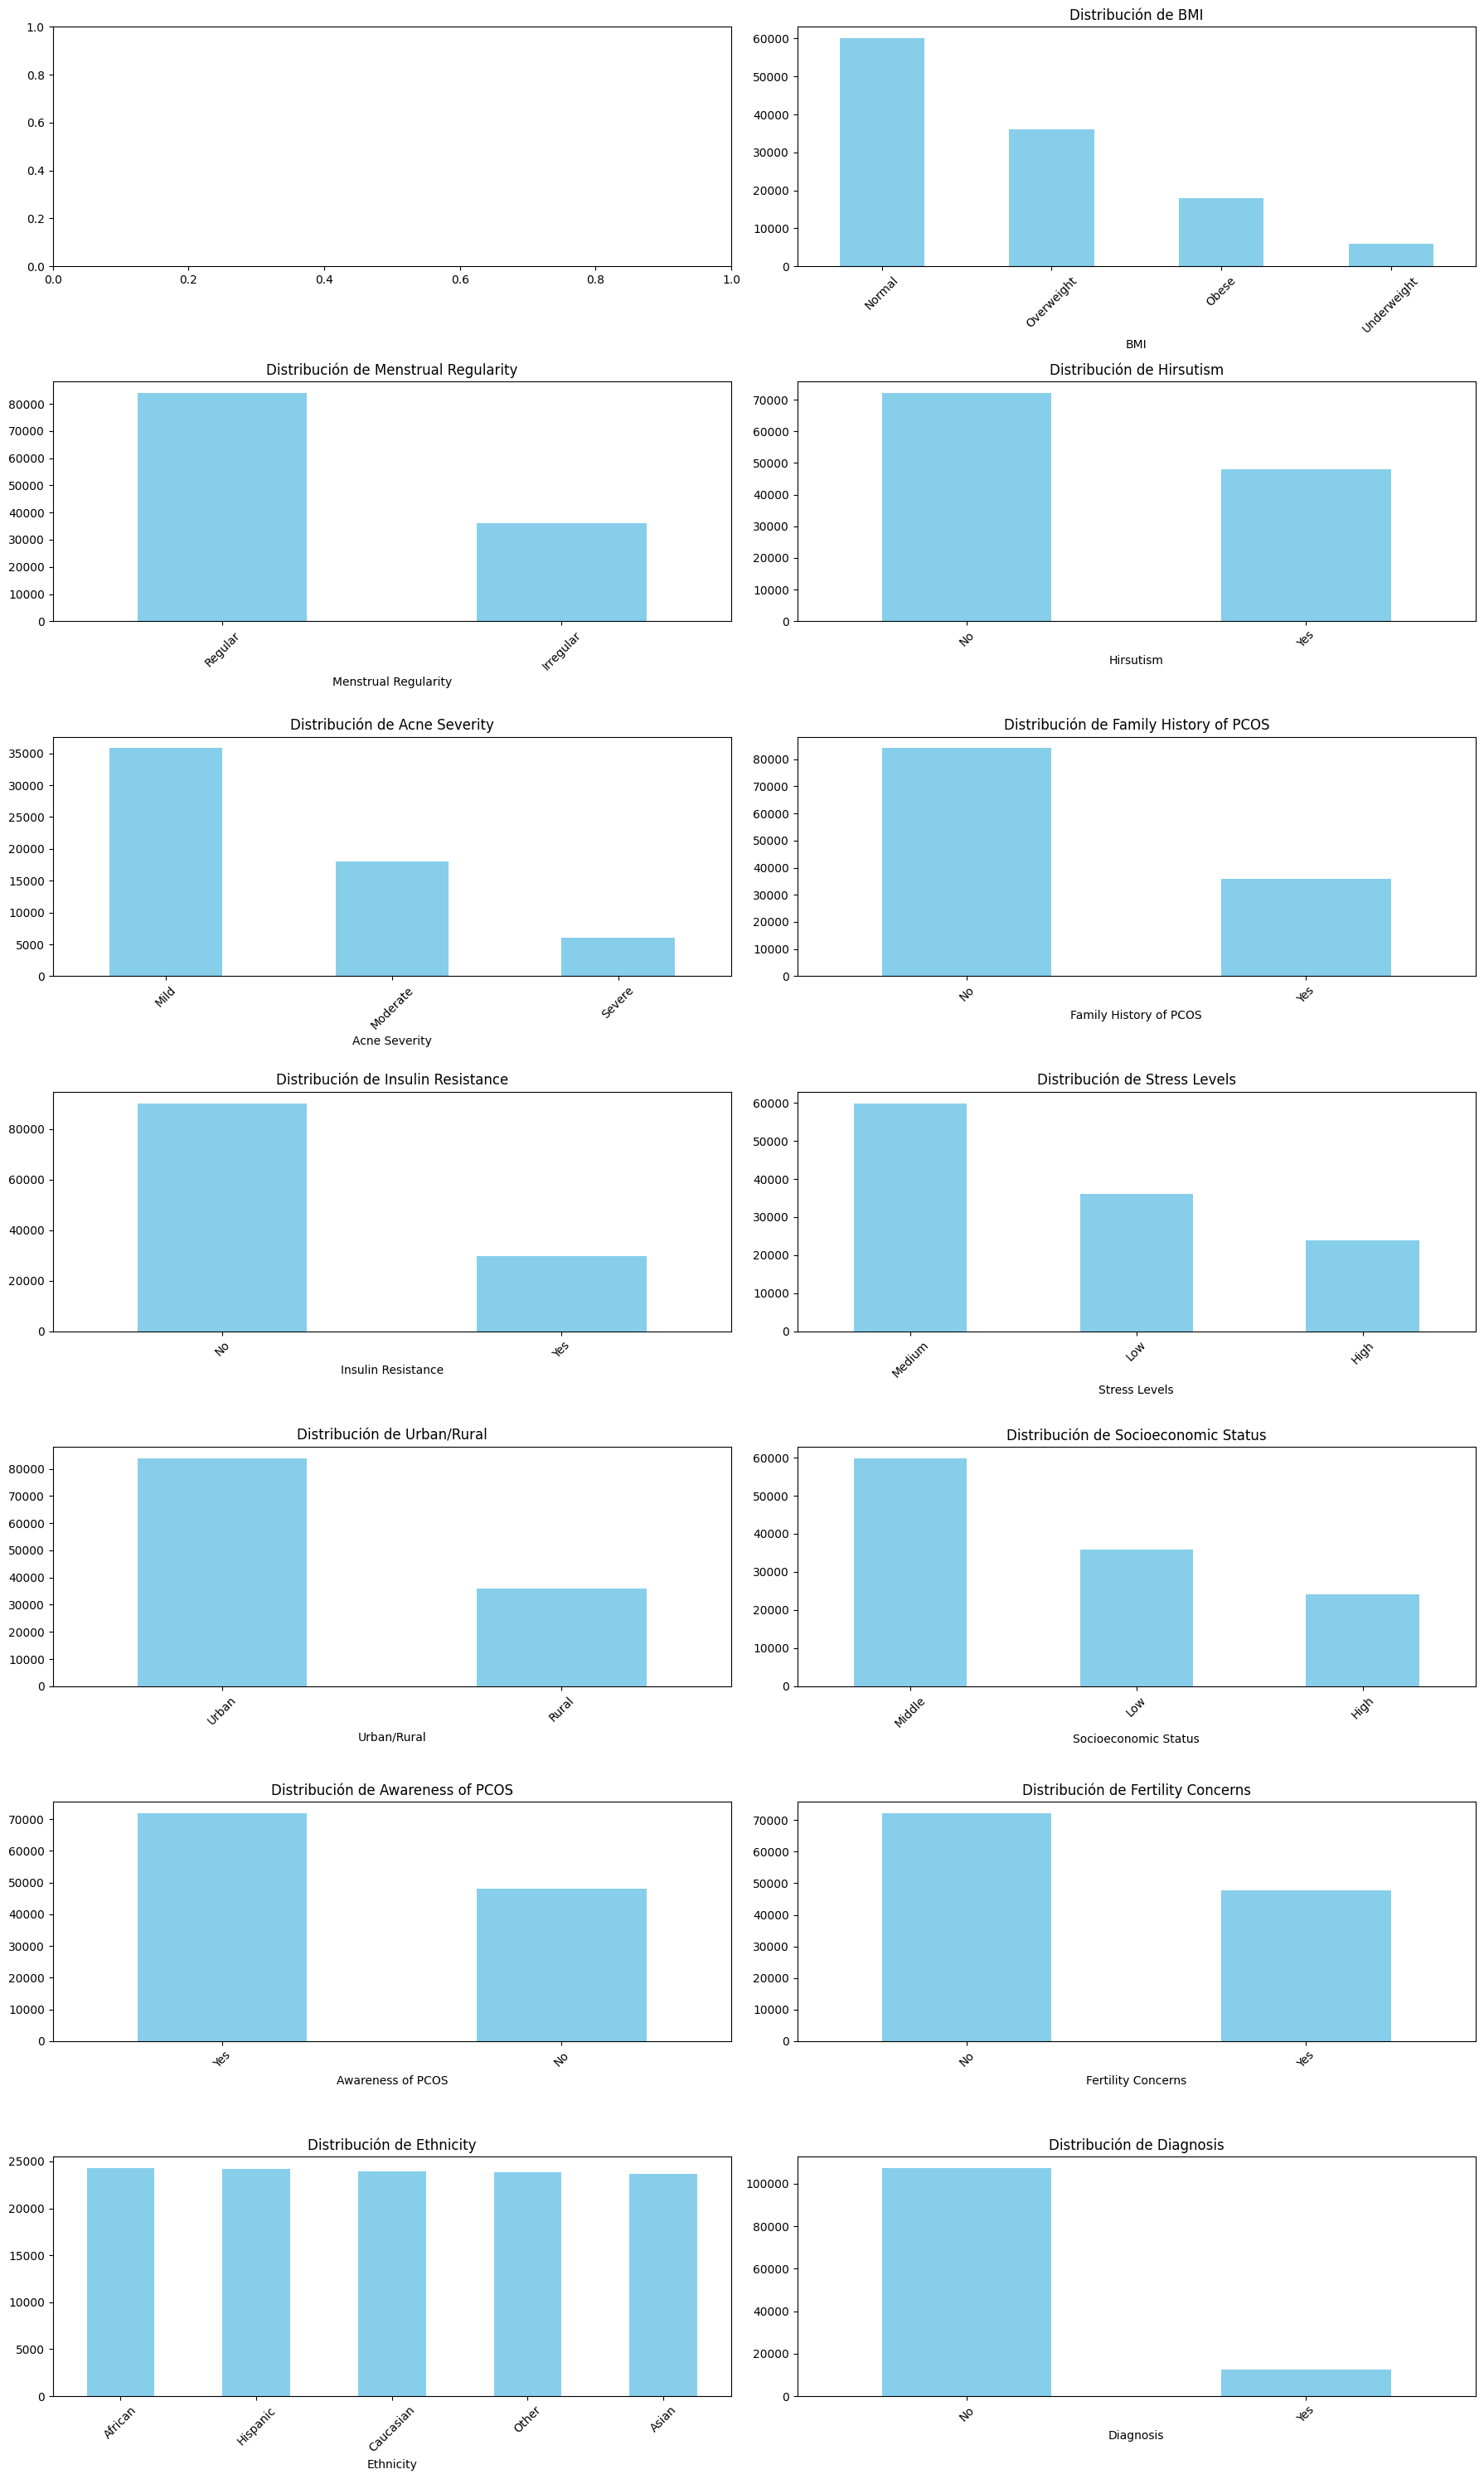

In [24]:
len(var_cat)
fig, axes = plt.subplots(7, 2, figsize=(18, 30))
axes = axes.ravel()

for i, var in enumerate(var_cat):
    if i == 0:
        continue
    data[var].value_counts().plot(kind="bar", ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribución de {var}")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(images_dir / "clasi_var_cat_bars.png")
plt.show()

## Análisis descriptivo

In [25]:
data[var_num].agg(["mean", "median", "std", "min", "max"])

,Age,Lifestyle Score,Undiagnosed PCOS Likelihood
mean,31.980508,5.506567,0.149937
median,32.000000,6.000000,0.149844
std,10.096799,2.871052,0.057786
min,15.000000,1.000000,0.050001
max,49.000000,10.000000,0.249998


In [26]:
data[var_cat].agg(["mode"])

,Country,BMI,Menstrual Regularity,Hirsutism,Acne Severity,Family History of PCOS,Insulin Resistance,Stress Levels,Urban/Rural,Socioeconomic Status,Awareness of PCOS,Fertility Concerns,Ethnicity,Diagnosis
,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode
0,Burkina Faso,Normal,Regular,No,Mild,No,No,Medium,Urban,Middle,Yes,No,African,No


## Correlación

### Correlacioń numérica

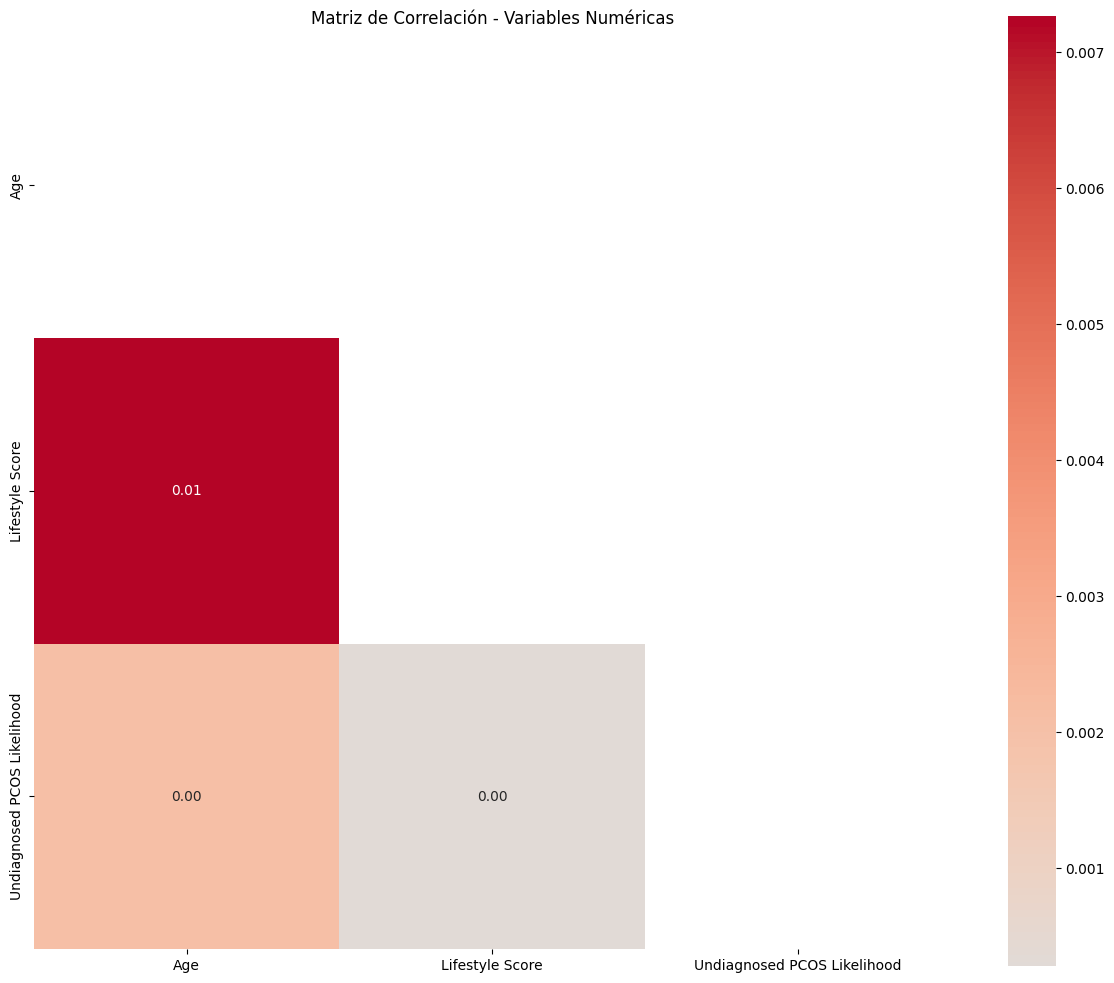

In [27]:
plt.figure(figsize=(12, 10))
corr = data.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.savefig(images_dir / "clasi_var_num_correlation.png")
plt.show()

## Datos atipicos

In [28]:
# Detección de outliers utilizando el método del IQR
outliers = {}

for col in var_num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[col] = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers[col])} outliers")

Age: 0 outliers
Lifestyle Score: 0 outliers
Undiagnosed PCOS Likelihood: 0 outliers


## Datos faltantes

In [29]:
from sklearn.impute import SimpleImputer

# Porcentaje de valores perdidos por variable #
def resum_missing(df):
    total = df.isnull().sum().sort_values(ascending=False)
    percent = (df.isnull().sum() *100/df.isnull().count()).sort_values(ascending=False)
    missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Porcentaje'])
    return missing_data

# Resumen de posición de valores perdidos #
def posmissing(df):
    lista_miss = np.where(df.isna())
    v1 = pd.Series(np.ndarray.tolist(lista_miss[0]))
    v2 = pd.Series(np.ndarray.tolist(lista_miss[1]))
    resumen_vna = pd.concat([v1, v2], axis=1, keys=['posicion_fila', 'posicion_columna'])
    return resumen_vna

# Construcción función que cuenta ceros #
def count_zeros(df):
    total = (df == 0).astype(int).sum(axis=0)
    percent = ((df == 0).astype(int).sum(axis=0) *100/df.count())
    missing_data = pd.concat([total, percent], axis=1, keys=['Total_ceros', 'Porcentaje'])
    return missing_data.sort_values(by='Porcentaje', ascending=False)

In [30]:
resum_missing(data)

,Total,Porcentaje
Acne Severity,60085,50.070833
Country,0,0.000000
Age,0,0.000000
Menstrual Regularity,0,0.000000
BMI,0,0.000000
Hirsutism,0,0.000000
Family History of PCOS,0,0.000000
Insulin Resistance,0,0.000000
Lifestyle Score,0,0.000000
Stress Levels,0,0.000000


In [31]:
data_imputed = data.copy()
cat_imp = SimpleImputer(strategy="most_frequent")
data_imputed[["Acne Severity"]] = cat_imp.fit_transform(data[["Acne Severity"]])


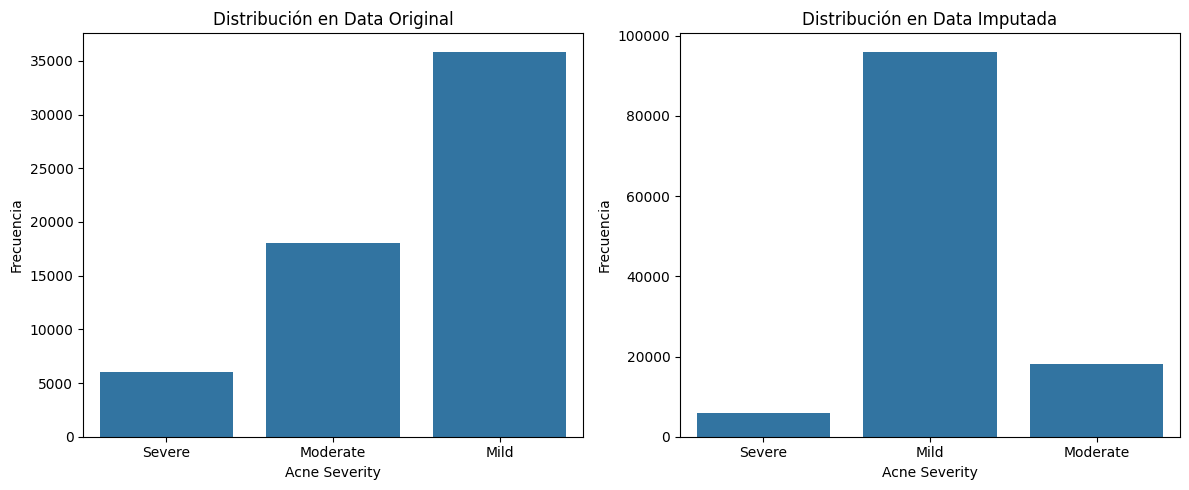

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=data, x="Acne Severity", ax=axes[0])
axes[0].set_title("Distribución en Data Original")
axes[0].set_xlabel("Acne Severity")
axes[0].set_ylabel("Frecuencia")

sns.countplot(data=data_imputed, x="Acne Severity", ax=axes[1])
axes[1].set_title("Distribución en Data Imputada")
axes[1].set_xlabel("Acne Severity")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig(images_dir / "clasi_imputacion_bars.png")
plt.show()

## Prueba de independencia de Chi-Cuadrado

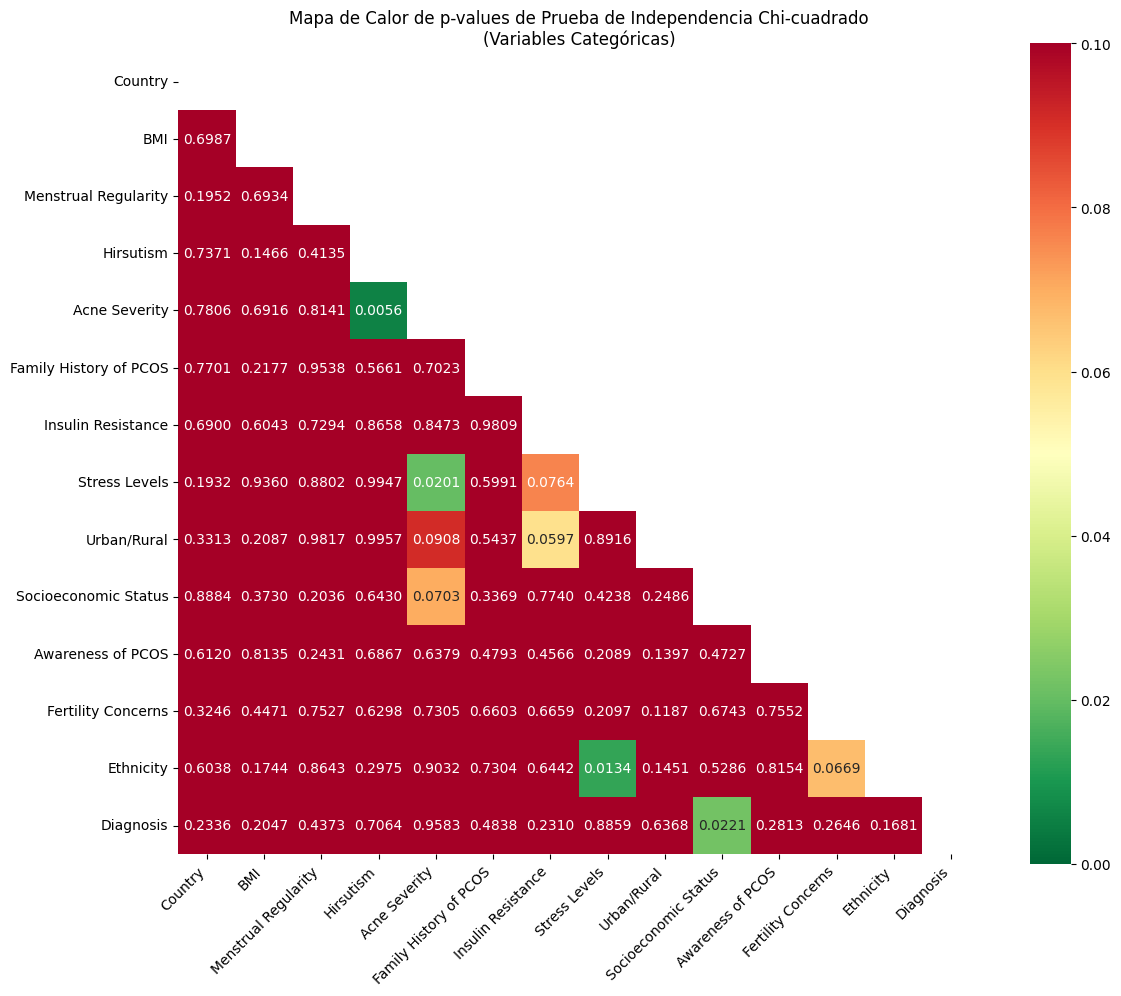

In [33]:
def prueba_independencia(df, var1, var2, alpha=0.05): 
    tabla_sin_totales = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, expected = chi2_contingency(tabla_sin_totales)
    return chi2, p, dof, expected
  
alpha = 0.05
n = len(var_cat)
p_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            p_matrix[i, j] = 1.0  # Diagonal, p=1 (independiente de sí mismo)
        else:
            _, p, _, _ = prueba_independencia(data_imputed, var_cat[i], var_cat[j], alpha)
            p_matrix[i, j] = p

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(p_matrix, dtype=bool))
sns.heatmap(p_matrix, mask=mask, annot=True, cmap='RdYlGn_r', center=alpha, fmt='.4f', square=True, vmin=0, vmax=0.1, xticklabels=var_cat, yticklabels=var_cat)
plt.title('Mapa de Calor de p-values de Prueba de Independencia Chi-cuadrado\n(Variables Categóricas)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(images_dir / "clasi_chi-square_heatmap.png")
plt.show()

## Anova

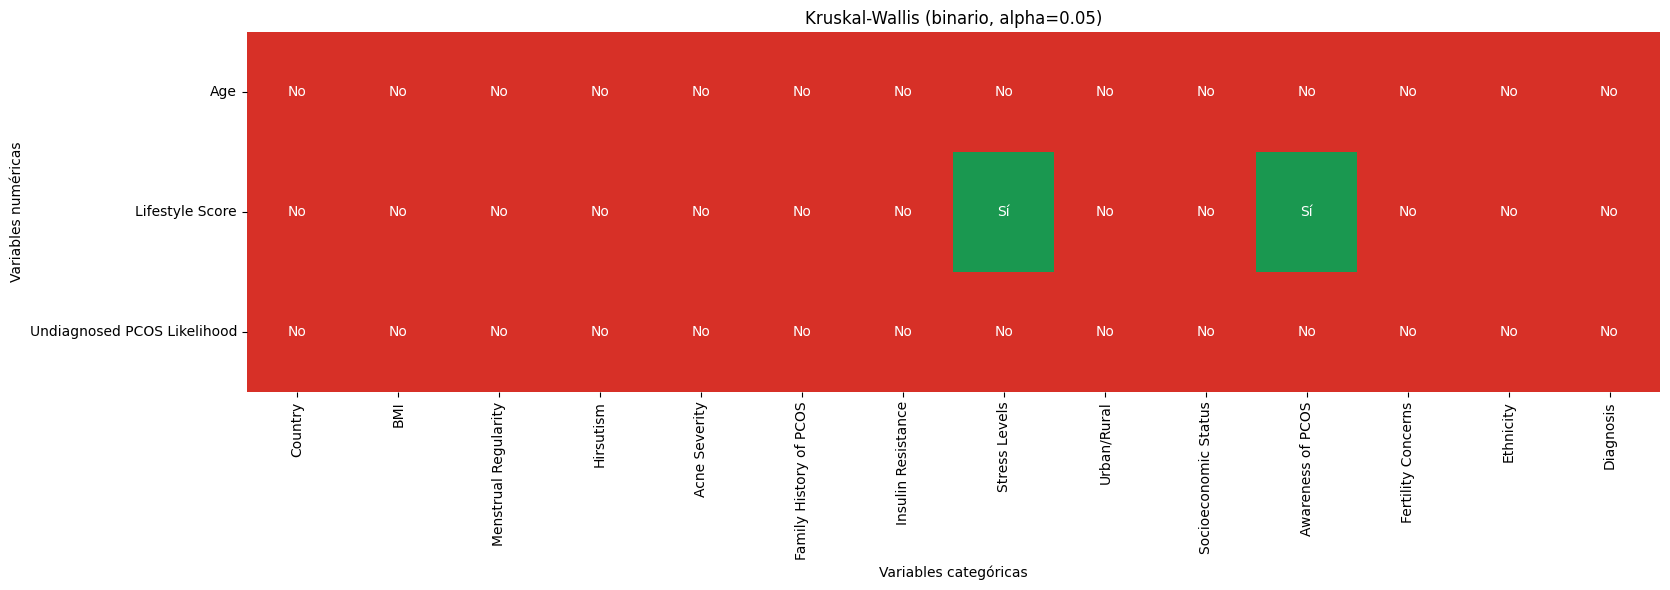

In [34]:
def kruskal_test(data, x, y):
    grupos = [g[y].values for _, g in data.groupby(x)]
    if len(grupos) < 2:
        return np.nan
    _, p = kruskal(*grupos)
    return p

# filas = numéricas, columnas = categóricas
pvals = pd.DataFrame(index=var_num, columns=var_cat, dtype=float)

for y in var_num:
    for x in var_cat:
        pvals.loc[y, x] = kruskal_test(data_imputed, x, y)

alpha = 0.05
sig = (pvals < alpha).astype(int)
sig_txt = sig.replace({0: "No", 1: "Sí"})
plt.figure(figsize=(max(10, 1.2*len(var_cat)), max(6, 0.55*len(var_num))))
sns.heatmap(sig, annot=sig_txt, fmt="", cbar=False, cmap=["#d73027", "#1a9850"])



plt.title(f"Kruskal-Wallis (binario, alpha={alpha})")
plt.xlabel("Variables categóricas")
plt.ylabel("Variables numéricas")
plt.tight_layout()
plt.savefig(images_dir / "clasi_anova_heatmap.png")
plt.show()